In [43]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
from langdetect import detect
from collections import Counter

In [44]:
# Read the CSV file
reviews_df = pd.read_csv("labeled_reviews_df.csv", sep = ';')
reviews_df.head()

,University Name,Review Text,Timestamp,Year,Manual_Category,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Reviews Count,Average Rating,Review Date,Review Rating,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match
0,University_6,"Не успела даже поступить, просто позвонила зад...",2021-08-06,2021,negative,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,University_2,Вчуся на факультеті управління фінансами і біз...,2023-04-02,2023,negative,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,University_20,я закончил наш харьковский радиотехникум и хот...,2021-07-31,2021,negative,0.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,University_1,Я обурена. Навіщо так багато платити за навчан...,2019-09-25,2019,negative,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,University_2,"А ти сиди ночами, зір втрачай, поставу, здоров...",2020-04-25,2020,negative,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              6468 non-null   object 
 1   Review Text                  6467 non-null   object 
 2   Timestamp                    6468 non-null   object 
 3   Year                         6468 non-null   int64  
 4   Manual_Category              1866 non-null   object 
 5   Attitude_Towards_Students    638 non-null    float64
 6   Campus_conditions            637 non-null    float64
 7   Corruption                   637 non-null    float64
 8   Academic_Process_Management  637 non-null    float64
 9   Education_Quality            637 non-null    float64
 10  Reviews Count                6275 non-null   float64
 11  Average Rating               6275 non-null   float64
 12  Review Date                  6351 non-null   object 
 13  Review Rating     

#### Convert data types to the required format

In [46]:
reviews_df["Match"] = reviews_df["Star_Sentiment_Category"] == reviews_df["Sentiment_Category_BERT"]

In [47]:
target_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

reviews_df[target_cols] = reviews_df[target_cols].astype("Int64")

In [48]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              6468 non-null   object 
 1   Review Text                  6467 non-null   object 
 2   Timestamp                    6468 non-null   object 
 3   Year                         6468 non-null   int64  
 4   Manual_Category              1866 non-null   object 
 5   Attitude_Towards_Students    638 non-null    Int64  
 6   Campus_conditions            637 non-null    Int64  
 7   Corruption                   637 non-null    Int64  
 8   Academic_Process_Management  637 non-null    Int64  
 9   Education_Quality            637 non-null    Int64  
 10  Reviews Count                6275 non-null   float64
 11  Average Rating               6275 non-null   float64
 12  Review Date                  6351 non-null   object 
 13  Review Rating     

#### Select only negative reviews for model training

In [49]:
filtered_df = reviews_df[
    (reviews_df["Sentiment_Category_BERT"] == "negative") &
    (reviews_df["Match"] == True) | (reviews_df["Manual_Category"] == "negative")
]

# Select only the required columns
negative_reviews_df = filtered_df[["University Name", "Review Text", "Year", "Attitude_Towards_Students", "Campus_conditions", "Corruption", "Academic_Process_Management", "Education_Quality"]].reset_index(drop=True)

# Preview the resulting DataFrame
negative_reviews_df.head()

,University Name,Review Text,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_6,"Не успела даже поступить, просто позвонила зад...",2021,1,0,0,0,0
1,University_2,Вчуся на факультеті управління фінансами і біз...,2023,0,0,1,0,1
2,University_20,я закончил наш харьковский радиотехникум и хот...,2021,0,0,1,1,0
3,University_1,Я обурена. Навіщо так багато платити за навчан...,2019,0,0,0,1,1
4,University_2,"А ти сиди ночами, зір втрачай, поставу, здоров...",2020,0,0,0,1,1


In [50]:
negative_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2490 entries, 0 to 2489
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   University Name              2490 non-null   object
 1   Review Text                  2490 non-null   object
 2   Year                         2490 non-null   int64 
 3   Attitude_Towards_Students    624 non-null    Int64 
 4   Campus_conditions            624 non-null    Int64 
 5   Corruption                   624 non-null    Int64 
 6   Academic_Process_Management  624 non-null    Int64 
 7   Education_Quality            624 non-null    Int64 
dtypes: Int64(5), int64(1), object(2)
memory usage: 167.9+ KB


# EDA

In [51]:
negative_reviews_df.shape

(2490, 8)

In [52]:
negative_reviews_df.describe()

,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
count,2490.000000,624.0,624.0,624.0,624.0,624.0
mean,2018.259839,0.31891,0.237179,0.299679,0.358974,0.456731
std,3.783350,0.466428,0.425694,0.458485,0.480085,0.498524
min,2009.000000,0.0,0.0,0.0,0.0,0.0
25%,2016.000000,0.0,0.0,0.0,0.0,0.0
50%,2019.000000,0.0,0.0,0.0,0.0,0.0
75%,2021.000000,1.0,0.0,1.0,1.0,1.0
max,2025.000000,1.0,1.0,1.0,1.0,1.0


In [53]:
negative_reviews_df.isnull().sum()[negative_reviews_df.isnull().sum()>0].sort_values(ascending=False)

Attitude_Towards_Students      1866
Campus_conditions              1866
Corruption                     1866
Academic_Process_Management    1866
Education_Quality              1866
dtype: int64

Keep missing values in the target columns, as they correspond to unlabeled reviews.
The goal is to train the model on labeled reviews and then apply it to the unlabeled.

### Duplicate detection

In [54]:
negative_reviews_df['Review Text'].nunique()

2357

In [55]:
duplicated= negative_reviews_df[negative_reviews_df['Review Text'].duplicated(keep=False)]

In [56]:
duplicated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 0 to 2467
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   University Name              263 non-null    object
 1   Review Text                  263 non-null    object
 2   Year                         263 non-null    int64 
 3   Attitude_Towards_Students    122 non-null    Int64 
 4   Campus_conditions            122 non-null    Int64 
 5   Corruption                   122 non-null    Int64 
 6   Academic_Process_Management  122 non-null    Int64 
 7   Education_Quality            122 non-null    Int64 
dtypes: Int64(5), int64(1), object(2)
memory usage: 19.8+ KB


In [57]:
# Sort the dataframe so that labeled reviews (with at least one non-null target value)
# appear first within each group of duplicate Review Text values

# Create a flag indicating whether the review has labels
negative_reviews_df["Has_Labels"] = (
    negative_reviews_df[target_cols]
    .notna()
    .any(axis=1)
)

# Put labeled rows first
negative_reviews_df = negative_reviews_df.sort_values(
    by="Has_Labels",
    ascending=False
)

# Remove duplicates, keeping the first row in each duplicate group
# (the labeled one, if available)
negative_reviews_df = negative_reviews_df.drop_duplicates(
    subset="Review Text",
    keep="first"
)

# Remove the helper column
negative_reviews_df = negative_reviews_df.drop(columns="Has_Labels")

In [58]:
negative_reviews_df.duplicated().sum()

np.int64(0)

In [59]:
negative_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2357 entries, 0 to 2489
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   University Name              2357 non-null   object
 1   Review Text                  2357 non-null   object
 2   Year                         2357 non-null   int64 
 3   Attitude_Towards_Students    622 non-null    Int64 
 4   Campus_conditions            622 non-null    Int64 
 5   Corruption                   622 non-null    Int64 
 6   Academic_Process_Management  622 non-null    Int64 
 7   Education_Quality            622 non-null    Int64 
dtypes: Int64(5), int64(1), object(2)
memory usage: 177.2+ KB


### Text length distribution

In [60]:
def preprocess_text_for_embeddings(text):
    """
    Minimal preprocessing before generating Sentence Embeddings.
    - Fix glued words after punctuation, e.g., "хорошо.Кто" -> "хорошо. Кто"
    - Removes extra spaces.
    - Ensures text is a clean string suitable for embedding models.
    """
    if not isinstance(text, str):
        return ""

    # Fix glued words after punctuation, e.g., "хорошо.Кто" -> "хорошо. Кто"
    clean_text = re.sub(
        r'([^\w\s])([^\s])',
        r'\1 \2',
        text
    )
    # Remove extra spaces
    cleaned_text = re.sub(r"\s+", " ", clean_text).strip()

    return cleaned_text

In [61]:
negative_reviews_df["Cleaned_Text"] = negative_reviews_df["Review Text"].apply(preprocess_text_for_embeddings) 

In [62]:
negative_reviews_df.head()

,University Name,Review Text,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text
0,University_6,"Не успела даже поступить, просто позвонила зад...",2021,1,0,0,0,0,"Не успела даже поступить, просто позвонила зад..."
420,University_11,"Учусь 5-й год в НГУ (магистратура), в целом вс...",2018,0,0,1,1,0,"Учусь 5- й год в НГУ ( магистратура) , в целом..."
413,University_7,Минусы\n- очень бедный и нищий факультет: все ...,2014,0,1,0,1,0,Минусы - очень бедный и нищий факультет: все а...
414,University_7,Во времена моей учебы ходила по универу такая ...,2012,0,0,0,0,1,Во времена моей учебы ходила по универу такая ...
415,University_7,Не самые лучшие годы моей жизни. В ДНУ все ник...,2011,0,0,0,1,0,Не самые лучшие годы моей жизни. В ДНУ все ник...


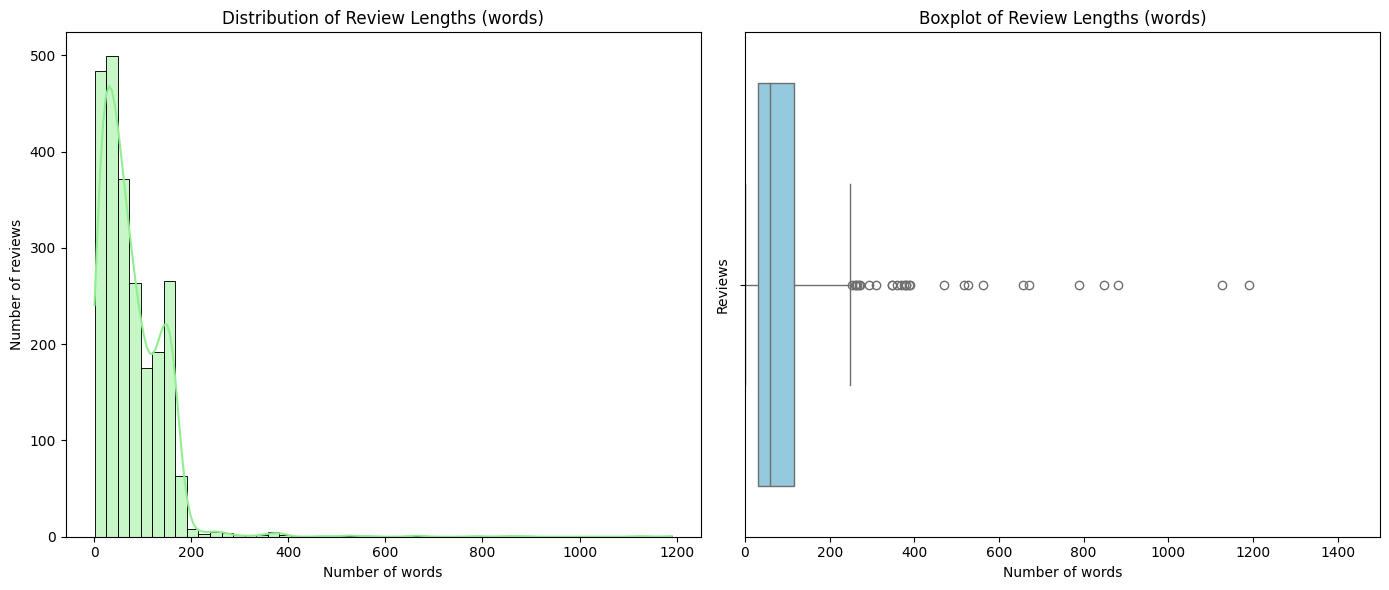

In [63]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 1500

# Compute word counts directly from text
word_lengths = negative_reviews_df["Cleaned_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = negative_reviews_df[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 1500)  # adjust to see the long tail

plt.tight_layout()
plt.show()

### Token Length Distribution

In [64]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
negative_reviews_df["token_length"] = negative_reviews_df["Cleaned_Text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

Token indices sequence length is longer than the specified maximum sequence length for this model (630 > 512). Running this sequence through the model will result in indexing errors


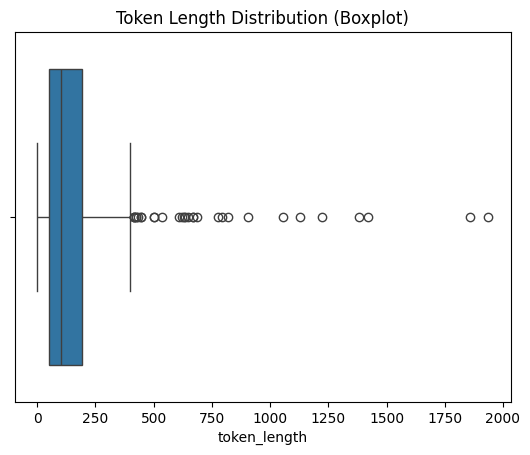

In [65]:
sns.boxplot(x=negative_reviews_df["token_length"])
plt.title("Token Length Distribution (Boxplot)")
plt.show()

In [66]:
(negative_reviews_df["token_length"] > 512).sum()

np.int64(20)

Token indices sequence length is longer than the specified maximum sequence length for this model (177 > 128). Running this sequence through the model will result in indexing errors


count    2357.000000
mean      130.649555
std       121.776760
min         1.000000
25%        52.000000
50%       104.000000
75%       193.000000
max      1937.000000
Name: token_length, dtype: float64
Number of texts that would be truncated:
max_length=128: 959 texts
max_length=256: 259 texts
max_length=512: 20 texts


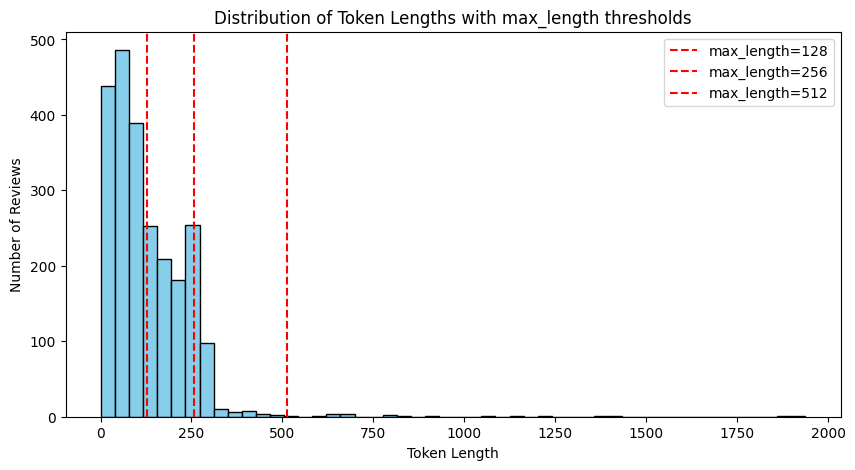

Embeddings shape: torch.Size([2357, 768])


In [67]:
# 1️⃣ Load the MPNet model
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
tokenizer = model.tokenizer

# 2️⃣ Calculate token length for each text (for EDA) using .tokenize() to avoid max_length issues
negative_reviews_df["token_length"] = negative_reviews_df["Cleaned_Text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

# 3️⃣ View basic statistics of token lengths
print(negative_reviews_df["token_length"].describe())

# 4️⃣ Count how many texts would be truncated at different max_length thresholds
max_lengths = [128, 256, 512]
truncated_counts = [(negative_reviews_df["token_length"] > ml).sum() for ml in max_lengths]

print("Number of texts that would be truncated:")
for ml, cnt in zip(max_lengths, truncated_counts):
    print(f"max_length={ml}: {cnt} texts")

# 5️⃣ Plot the distribution of token lengths and mark max_length thresholds
plt.figure(figsize=(10,5))
plt.hist(negative_reviews_df["token_length"], bins=50, color='skyblue', edgecolor='black')
for ml in max_lengths:
    plt.axvline(ml, color='red', linestyle='--', label=f'max_length={ml}')
plt.xlabel("Token Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Token Lengths with max_length thresholds")
plt.legend()
plt.show()

# 6️⃣ Generate embeddings with MPNet, setting max_length to 512 to minimize truncation
# Short texts are fully processed; only extremely long texts are truncated
texts = negative_reviews_df["Cleaned_Text"].tolist()
embeddings = model.encode(
    texts,
    convert_to_tensor=True,
    max_length=512,   # MPNet physical limit
    truncation=True   # truncate only texts longer than max_length
)

print(f"Embeddings shape: {embeddings.shape}")

We set max_seq_length=512 because MPNet can handle up to 512 tokens, which preserves most of the information in the reviews. Reviews longer than 512 tokens are removed instead of truncated to avoid losing content that may be important for multi-label targets. This ensures that the model trains only on complete and correct data.

Removed 20 texts longer than 512 tokens
Removed 59 texts shorter than 10 tokens
Remaining texts: 2278
count    2278.000000
mean      126.680860
std        87.021628
min        10.000000
25%        55.000000
50%       106.000000
75%       193.000000
max       502.000000
Name: token_length, dtype: float64


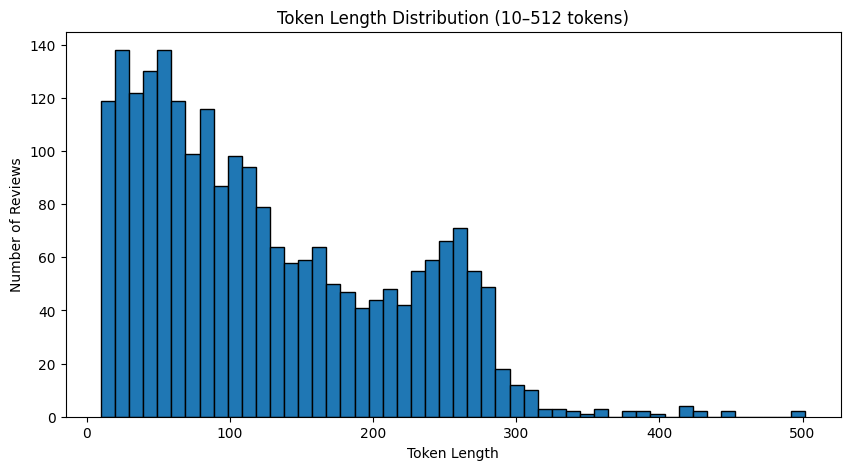

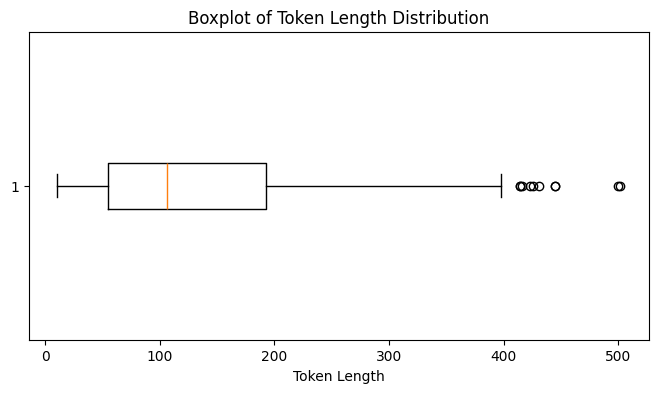

In [68]:
# Define limits
min_tokens = 10
max_seq_length = 512

original_size = len(negative_reviews_df)

# Remove texts longer than 512 tokens
negative_reviews_df = negative_reviews_df[negative_reviews_df["token_length"] <= max_seq_length]
print(f"Removed {original_size - len(negative_reviews_df)} texts longer than {max_seq_length} tokens")

size_after_long_filter = len(negative_reviews_df)

# Remove texts shorter than 20 tokens
negative_reviews_df = negative_reviews_df[negative_reviews_df["token_length"] >= min_tokens]
print(f"Removed {size_after_long_filter - len(negative_reviews_df)} texts shorter than {min_tokens} tokens")

print(f"Remaining texts: {len(negative_reviews_df)}")

# Show new distribution
print(negative_reviews_df["token_length"].describe())

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(negative_reviews_df["token_length"], bins=50, edgecolor='black')
plt.xlabel("Token Length")
plt.ylabel("Number of Reviews")
plt.title(f"Token Length Distribution ({min_tokens}–{max_seq_length} tokens)")
plt.show()

# Boxplot to visualize spread and potential outliers
plt.figure(figsize=(8,4))
plt.boxplot(negative_reviews_df["token_length"], vert=False)
plt.xlabel("Token Length")
plt.title("Boxplot of Token Length Distribution")
plt.show()

In [69]:
negative_reviews_df["token_length"].quantile([0.05, 0.25, 0.5, 0.75, 0.9, 0.95])

0.05     19.0
0.25     55.0
0.50    106.0
0.75    193.0
0.90    258.0
0.95    276.0
Name: token_length, dtype: float64

### Correlation of token length

In [70]:
# Select only class columns and token length
cols = target_cols + ['token_length']

# Compute correlation matrix
corr_matrix = negative_reviews_df[cols].corr()

# Extract correlation of token_length with each class
token_corr = corr_matrix['token_length'].drop('token_length')

# Print results sorted by correlation strength
print("Correlation of token length with categories:\n")
print(token_corr.sort_values(ascending=False))

Correlation of token length with categories:

Academic_Process_Management    0.252273
Education_Quality              0.211193
Campus_conditions              0.103828
Attitude_Towards_Students      0.064693
Corruption                    -0.029531
Name: token_length, dtype: float64


### Class imbalance detection

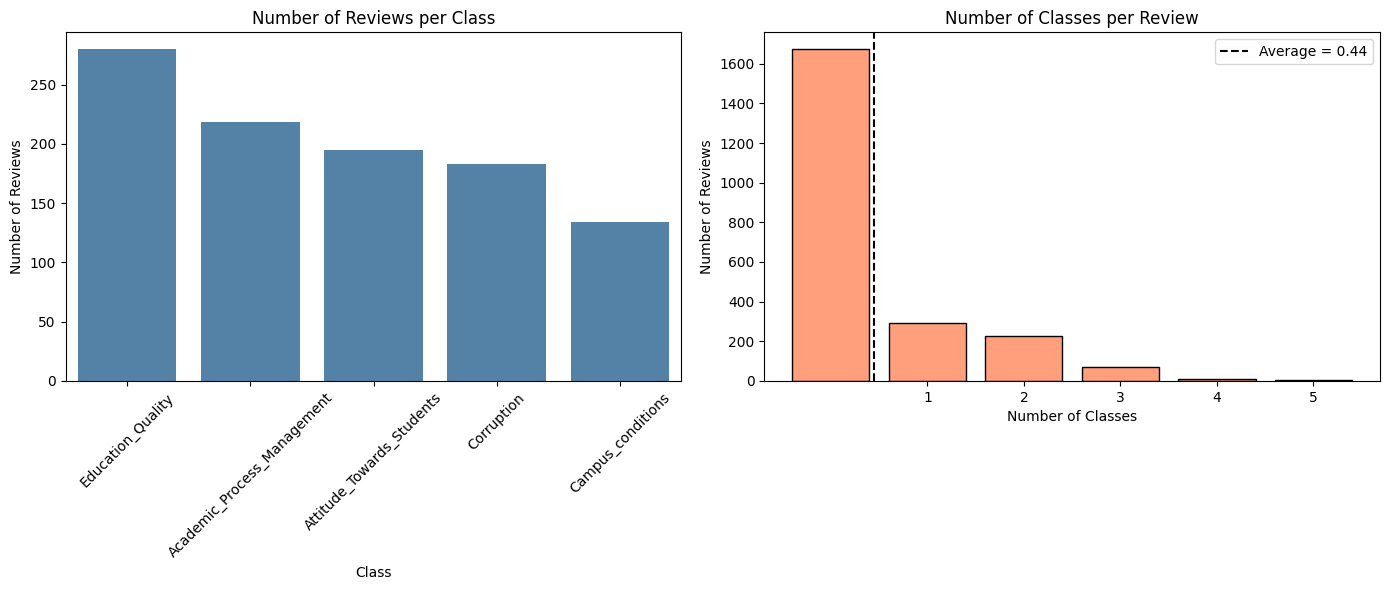

In [71]:

# 1️⃣ Count of reviews per class
class_counts = negative_reviews_df[target_cols].sum().sort_values(ascending=False)
plot_df_counts = class_counts.reset_index()
plot_df_counts.columns = ['Class', 'Count']

# 2️⃣ Number of classes per review
num_classes = negative_reviews_df[target_cols].sum(axis=1)
max_classes = int(num_classes.max())
bins = range(1, max_classes + 2)

# Calculate the average number of classes per review
avg_classes = num_classes.mean()

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — bar plot of counts per class
sns.barplot(data=plot_df_counts, x='Class', y='Count', color='steelblue', ax=axes[0])
axes[0].set_title("Number of Reviews per Class")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xlabel("Class")
axes[0].tick_params(axis='x', rotation=45)

# Right plot — histogram of number of classes per review
sns.histplot(num_classes, bins=bins, color='coral', discrete=True, shrink=0.8, ax=axes[1])
axes[1].axvline(avg_classes, color='black', linestyle='--', label=f"Average = {avg_classes:.2f}")
axes[1].set_title("Number of Classes per Review")
axes[1].set_xlabel("Number of Classes")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks(bins[:-1])
axes[1].legend()

plt.tight_layout()
plt.show()

### Create a co-occurrence matrix
- This shows how often different categories are labeled together by users
-  Understanding these patterns can directly influence model architecture decisions
- The interpretation of the results

In [72]:
# Replace missing values with 0 before calculating label co-occurrence
# because unlabeled reviews contain NaN values in the target columns.
co_occurrence = (
    negative_reviews_df[target_cols]
    .fillna(0)
    .astype(int)
    .T
    .dot(
        negative_reviews_df[target_cols]
        .fillna(0)
        .astype(int)
    )
)

# Convert the result to integers so heatmap annotations display correctly
co_occurrence = co_occurrence.astype(int)
co_occurrence

,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
Attitude_Towards_Students,195,35,50,65,71
Campus_conditions,35,134,26,42,43
Corruption,50,26,183,35,75
Academic_Process_Management,65,42,35,218,81
Education_Quality,71,43,75,81,280


### Distribution Across Languages

Before training a multi-label classification model, it's important to ensure that categories are not biased by language.
If certain categories appear predominantly in one language (e.g., Russian vs. Ukrainian), the model might learn to predict the language rather than the actual features of the review.

The following analysis examines how each review category is distributed between Ukrainian and Russian reviews.

In [73]:
# Define a safe detection function
def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Apply to the review text column
negative_reviews_df["Language"] = negative_reviews_df["Cleaned_Text"].apply(detect_lang)

In [74]:
negative_reviews_df.head()

,University Name,Review Text,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,token_length,Language
0,University_6,"Не успела даже поступить, просто позвонила зад...",2021,1,0,0,0,0,"Не успела даже поступить, просто позвонила зад...",85,ru
420,University_11,"Учусь 5-й год в НГУ (магистратура), в целом вс...",2018,0,0,1,1,0,"Учусь 5- й год в НГУ ( магистратура) , в целом...",177,ru
413,University_7,Минусы\n- очень бедный и нищий факультет: все ...,2014,0,1,0,1,0,Минусы - очень бедный и нищий факультет: все а...,186,ru
414,University_7,Во времена моей учебы ходила по универу такая ...,2012,0,0,0,0,1,Во времена моей учебы ходила по универу такая ...,236,ru
415,University_7,Не самые лучшие годы моей жизни. В ДНУ все ник...,2011,0,0,0,1,0,Не самые лучшие годы моей жизни. В ДНУ все ник...,27,ru


In [75]:
negative_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2278 entries, 0 to 2489
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   University Name              2278 non-null   object
 1   Review Text                  2278 non-null   object
 2   Year                         2278 non-null   int64 
 3   Attitude_Towards_Students    603 non-null    Int64 
 4   Campus_conditions            603 non-null    Int64 
 5   Corruption                   603 non-null    Int64 
 6   Academic_Process_Management  603 non-null    Int64 
 7   Education_Quality            603 non-null    Int64 
 8   Cleaned_Text                 2278 non-null   object
 9   token_length                 2278 non-null   int64 
 10  Language                     2278 non-null   object
dtypes: Int64(5), int64(2), object(4)
memory usage: 224.7+ KB


In [76]:
# Групуємо за мовою і сумуємо по кожному класу
lang_category_counts = negative_reviews_df.groupby("Language")[target_cols].sum()

# Виводимо результат
lang_category_counts
#  Відносна частка по колонках (кожен клас ділиться на суму по класу)
lang_category_percent = lang_category_counts.div(lang_category_counts.sum(axis=0), axis=1)

# Вивід
lang_category_percent.round(3)

,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
Language,,,,,
bg,0.0,0.0,0.005,0.0,0.0
en,0.0,0.0,0.0,0.0,0.0
ru,0.426,0.56,0.464,0.394,0.468
uk,0.574,0.44,0.53,0.606,0.532


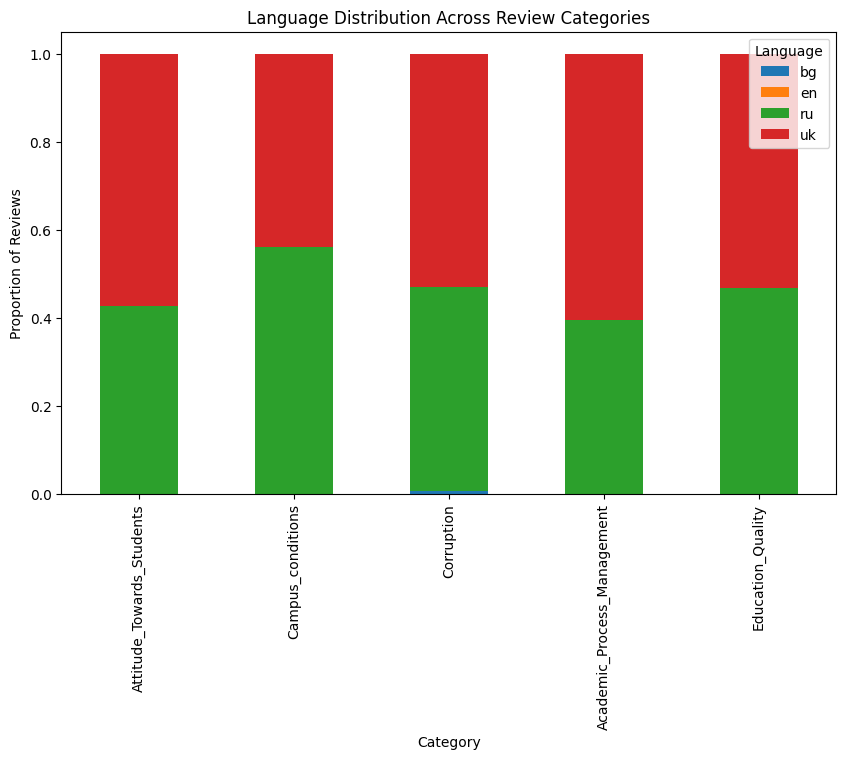

In [77]:
lang_category_percent.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Language Distribution Across Review Categories")
plt.xlabel("Category")
plt.ylabel("Proportion of Reviews")
plt.legend(title="Language")

plt.show()

A heatmap was used to analyze how review categories are distributed across languages.
This analysis helps detect potential language bias in the dataset.
If certain categories appear predominantly in one language, the model may learn language patterns instead of the semantic meaning of the reviews.

### chi2

Perform chi-square tests to examine whether the distribution of target labels
differs significantly across review languages.
This helps identify potential language-related bias in the dataset

In [78]:
from scipy.stats import chi2_contingency

for label in target_cols:
    contingency_table = pd.crosstab(negative_reviews_df['Language'], negative_reviews_df[label])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"{label}: p-value = {p:.4f}")

Attitude_Towards_Students: p-value = 0.4742
Campus_conditions: p-value = 0.0193
Corruption: p-value = 0.2942
Academic_Process_Management: p-value = 0.0596
Education_Quality: p-value = 0.5463


Campus_conditions demonstrated a
statistically significant relationship with language,
suggesting a potential language-related difference in topic prevalence.

### Top words frequency

In [79]:
all_words = " ".join(negative_reviews_df["Cleaned_Text"]).split()

unique_words = len(set(all_words))
total_words = len(all_words)

vocab_richness = unique_words / total_words
print(vocab_richness)

0.25169232209409137


The Type–Token Ratio (TTR) of the dataset is 0.25, indicating relatively high lexical diversity in the review texts.

### Rare words ratio

In [80]:
word_counts = Counter(all_words)

rare_words = [w for w, c in word_counts.items() if c == 1]

rare_ratio = len(rare_words) / len(word_counts)

print(rare_ratio)

0.6829307980194798


About 68% of unique words appear only once, which is normal for user-generated reviews and does not pose a problem for transformer-based models

### Zipf plot

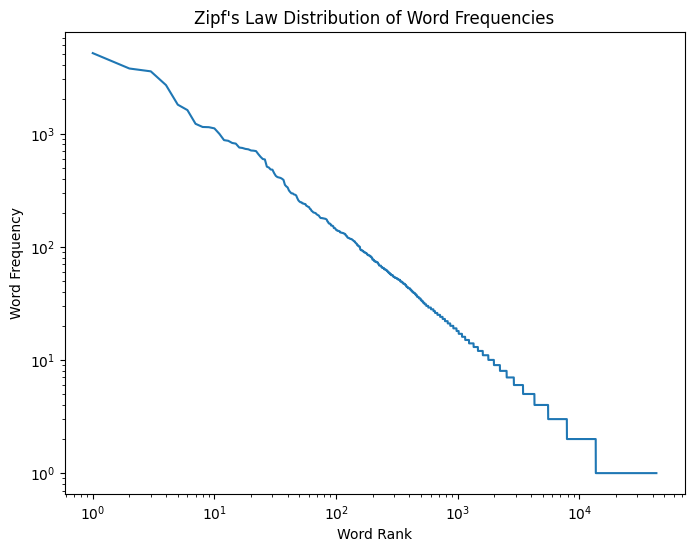

In [81]:
# Count word frequencies
word_counts = Counter(all_words)

# Sort frequencies
freqs = sorted(word_counts.values(), reverse=True)

# Generate ranks
ranks = np.arange(1, len(freqs) + 1)

# Plot Zipf curve
plt.figure(figsize=(8,6))
plt.loglog(ranks, freqs)

plt.xlabel("Word Rank")
plt.ylabel("Word Frequency")
plt.title("Zipf's Law Distribution of Word Frequencies")

plt.show()

Zipf’s law is mostly followed; small zigzags in the tail correspond to rare or misspelled words, which is normal for user-generated text.

In [82]:
# Remove the helper column
negative_reviews_df = negative_reviews_df.drop(columns=['token_length'])

In [83]:
negative_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2278 entries, 0 to 2489
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   University Name              2278 non-null   object
 1   Review Text                  2278 non-null   object
 2   Year                         2278 non-null   int64 
 3   Attitude_Towards_Students    603 non-null    Int64 
 4   Campus_conditions            603 non-null    Int64 
 5   Corruption                   603 non-null    Int64 
 6   Academic_Process_Management  603 non-null    Int64 
 7   Education_Quality            603 non-null    Int64 
 8   Cleaned_Text                 2278 non-null   object
 9   Language                     2278 non-null   object
dtypes: Int64(5), int64(1), object(4)
memory usage: 206.9+ KB


In [84]:
negative_reviews_df.to_csv('negative_reviews_df.csv', index = False)